# Ejercicio Práctico Semana 2  
## Extracción y Transformación Estratégica de Datos (Caso Olist)

### Grupo 7
- John Plazarte
- Eddy Mantilla
- Christian Carrera

### Objetivo:
Construir un pipeline de datos en Python que permita integrar información de distintas fuentes (Web Scraping + API) para análisis estratégico del mercado tecnológico.

In [1]:
# Librerías necesarias
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import numpy as np
import json

## PUNTO 1: WEB SCRAPING
Fase de Extracción: Inteligencia Competitiva (Web Scraping) La empresa necesita monitorear los precios de los computadores de su competidor directo. Su código debe conectarse a la página de pruebas del competidor (https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops) para extraer el Nombre, el Precio y la Descripción, almacenándolos en un DataFrame de Pandas.

In [2]:
# =========================================
# FASE 1: EXTRACCIÓN - WEB SCRAPING
# =========================================

url = "https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops"
datos_scraping = []
# Programación defensiva: manejo de errores
try:
    respuesta = requests.get(url, timeout=10)

    # Validar que la respuesta sea exitosa
    respuesta.raise_for_status()

    soup = BeautifulSoup(respuesta.text, "html.parser")
    productos = soup.find_all("div", class_="thumbnail")

    # Scraping de productos
    for producto in productos:
        try:
            # =========================
            # VALIDACIONES DEFENSIVAS
            # =========================

            # Nombre
            a_nombre = producto.find("a", class_="title")
            nombre_producto = a_nombre.text.strip() if a_nombre else "sin_nombre"

            # Precio
            h4_precio = producto.find("h4", class_="price")
            precio = h4_precio.text.strip() if h4_precio else "0"

            # Descripción
            p_desc = producto.find("p", class_="description")
            descripcion = p_desc.text.strip() if p_desc else "sin_descripcion"

            # =========================
            # GUARDAR DATOS
            # =========================
            datos_scraping.append({
                "Nombre_Producto": nombre_producto,
                "Precio": precio,
                "Descripcion": descripcion
            })
        except Exception as e:
            # Si un producto falla, no rompe todo el proceso
            print(f"Error procesando producto: {e}")

    # DataFrame de Pandas.
    df_scraping = pd.DataFrame(datos_scraping)
    print(f"✅ Scraping completado: {len(df_scraping)} productos extraídos.")
    display(df_scraping.head())
    df_scraping.info()

except requests.exceptions.RequestException as e:
    print(f"❌ Error crítico en el Web Scraping: {e}")

✅ Scraping completado: 117 productos extraídos.


,Nombre_Producto,Precio,Descripcion
0,Asus VivoBook...,$295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14..."
1,Prestigio Smar...,$299,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ..."
2,Prestigio Smar...,$299,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ..."
3,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,$321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Nombre_Producto  117 non-null    object
 1   Precio           117 non-null    object
 2   Descripcion      117 non-null    object
dtypes: object(3)
memory usage: 2.9+ KB


## PUNTO 2: API FAKESTORE
Fase de Extracción: Integración de Nuevos Proveedores (API) Para tener poder de negociación, necesitamos evaluar el catálogo de un nuevo proveedor de tecnología. Su solución debe consumir los datos de la API pública FakeStore (https://fakestoreapi.com/products/category/electronics) para descargar la categoría completa en formato JSON, extraer los campos relevantes (como Título, Precio y Rating) y convertirlos en un segundo DataFrame.

In [3]:
# =========================================
# FASE 2: EXTRACCIÓN - API
# =========================================

api_url = "https://fakestoreapi.com/products/category/electronics"
data_api = []

# Programación defensiva: manejo de errores
try:
    # Conexión API
    respuesta = requests.get(api_url, timeout=10)

    # Validar que la respuesta sea exitosa
    if respuesta.status_code == 200:
        productos_api = respuesta.json()
        for producto in productos_api:
            try:
                # =========================
                # VALIDACIONES DEFENSIVAS
                # =========================

                titulo = producto.get("title") or "sin_nombre"
                precio = producto.get("price") or 0
                rating = producto.get("rating", {}).get("rate") or 0

                # =========================
                # GUARDAR DATOS
                # =========================
                data_api.append({
                    "Nombre_Producto": titulo,
                    "Precio": precio,
                    "Rating": rating
                })
            except Exception as e:
                # Si un producto falla, no rompe todo el proceso
                print(f"Error procesando item API: {e}")

        # Segundo DataFrame
        df_api = pd.DataFrame(data_api)
        print(f"✅ API completada: {len(df_api)} productos descargados.")
        display(df_api.head())
        df_api.info()

    else:
        print(f"⚠️La API respondió con código: {respuesta.status_code}")

except requests.exceptions.RequestException as e:
    print(f"❌ Error al conectar con la API: {e}")

✅ API completada: 6 productos descargados.


,Nombre_Producto,Precio,Rating
0,WD 2TB Elements Portable External Hard Drive -...,64.0,3.3
1,SanDisk SSD PLUS 1TB Internal SSD - SATA III 6...,109.0,2.9
2,Silicon Power 256GB SSD 3D NAND A55 SLC Cache ...,109.0,4.8
3,WD 4TB Gaming Drive Works with Playstation 4 P...,114.0,4.8
4,Acer SB220Q bi 21.5 inches Full HD (1920 x 108...,599.0,2.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre_Producto  6 non-null      object 
 1   Precio           6 non-null      float64
 2   Rating           6 non-null      float64
dtypes: float64(2), object(1)
memory usage: 276.0+ bytes


## PUNTO 3: Fase de Transformación:
 Estandarización y Calidad del Dato Al tener dos fuentes de información con estructuras distintas, su solución en Python debe aplicar las reglas de limpieza y formateo necesarias para unificarlas. Esto incluye estandarizar los tipos de datos (asegurando que los precios puedan operarse matemáticamente), gestionar adecuadamente los valores nulos o vacíos, y crear una dimensión de trazabilidad que indique el origen de cada registro. El resultado de esta fase debe ser la consolidación de ambas fuentes en un único catálogo maestro impecable.

In [4]:
#Validamos el tipo de dato de Precio y vemos como esta compuesto el campo precio
df_scraping.info()
display(df_scraping.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Nombre_Producto  117 non-null    object
 1   Precio           117 non-null    object
 2   Descripcion      117 non-null    object
dtypes: object(3)
memory usage: 2.9+ KB


,Nombre_Producto,Precio,Descripcion
0,Asus VivoBook...,$295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14..."
1,Prestigio Smar...,$299,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ..."
2,Prestigio Smar...,$299,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ..."
3,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,$321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1..."


In [5]:
# 1. Limpieza de Precios: Eliminar símbolos y convertir a float
df_scraping['Precio'] = df_scraping['Precio'].replace(r'[\$,]', '', regex=True).astype(float)

In [6]:
df_scraping.info()
display(df_scraping.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre_Producto  117 non-null    object 
 1   Precio           117 non-null    float64
 2   Descripcion      117 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.9+ KB


,Nombre_Producto,Precio,Descripcion
0,Asus VivoBook...,295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14..."
1,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ..."
2,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ..."
3,Aspire E1-510,306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1..."


In [7]:
# Extraer rating
# df_api['Rating'] = df_api['Rating'].apply(lambda x: x['rate'] if isinstance(x, dict) else np.nan) # This line is removed as Rating is already a float

# Añadir columnas faltantes
df_scraping['Rating'] = np.nan
df_api['Descripcion'] = np.nan

# Trazabilidad
df_scraping['source'] = 'competitor_web'
df_api['source'] = 'supplier_api'

# Unificar columnas
df_scraping = df_scraping[['Nombre_Producto', 'Precio', 'Descripcion', 'Rating', 'source']]
df_api = df_api[['Nombre_Producto', 'Precio', 'Descripcion', 'Rating', 'source']]

In [8]:
# Consolidación
df_master = pd.concat([df_scraping, df_api], ignore_index=True)
df_master.info()
display(df_master.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre_Producto  123 non-null    object 
 1   Precio           123 non-null    float64
 2   Descripcion      117 non-null    object 
 3   Rating           6 non-null      float64
 4   source           123 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.9+ KB


,Nombre_Producto,Precio,Descripcion,Rating,source
0,Asus VivoBook...,295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14...",NaN,competitor_web
1,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ...",NaN,competitor_web
2,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ...",NaN,competitor_web
3,Aspire E1-510,306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",NaN,competitor_web
4,Lenovo V110-15...,321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1...",NaN,competitor_web


In [9]:
# Manejo de nulos
# sustituyendo cada valor nulo por el precio promedio de todos los productos en esa misma columna.
df_master['Precio'] = df_master['Precio'].fillna(df_master['Precio'].mean())
# sustituyendo cada valor nulo encontrado en la columna 'Rating' con un 0
df_master['Rating'] = df_master['Rating'].fillna(0)
df_master.info()
df_master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nombre_Producto  123 non-null    object 
 1   Precio           123 non-null    float64
 2   Descripcion      117 non-null    object 
 3   Rating           123 non-null    float64
 4   source           123 non-null    object 
dtypes: float64(2), object(3)
memory usage: 4.9+ KB


,Nombre_Producto,Precio,Descripcion,Rating,source
0,Asus VivoBook...,295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14...",0.0,competitor_web
1,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ...",0.0,competitor_web
2,Prestigio Smar...,299.00,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ...",0.0,competitor_web
3,Aspire E1-510,306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",0.0,competitor_web
4,Lenovo V110-15...,321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1...",0.0,competitor_web


Se imputaron valores nulos en la columna Precio utilizando la media para evitar sesgos, mientras que en Rating se asignó 0 al representar ausencia de valoración.

## PUNTO 4: Resultado de Negocio:
Para demostrar a la junta directiva el valor analítico de los datos integrados, su solución debe calcular e imprimir automáticamente en pantalla al menos dos Indicadores Clave de Desempeño (KPIs) o métricas estratégicas que usted considere relevantes basándose en el catálogo consolidado (por ejemplo, análisis de precios, comparativas o promedios del mercado).

## 🎯 KPI 1: Precio promedio por fuente

In [10]:
kpi_price = df_master.groupby('source')['Precio'].mean()
print("Precio promedio por fuente:")
print(kpi_price)

Precio promedio por fuente:
source
competitor_web    909.393846
supplier_api      332.498333
Name: Precio, dtype: float64


##🎯 KPI 2: Producto más caro del mercado

In [11]:
max_price_product = df_master.loc[df_master['Precio'].idxmax()]
print("\nProducto más caro:")
print(max_price_product)


Producto más caro:
Nombre_Producto                                    Asus ROG Strix...
Precio                                                        1799.0
Descripcion        Asus ROG Strix SCAR Edition GL503VM-ED115T, 15...
Rating                                                           0.0
source                                                competitor_web
Name: 116, dtype: object


##🎯 KPI 3: Diferencia de precios

In [12]:
avg_competitor = df_master[df_master['source']=='competitor_web']['Precio'].mean()
avg_supplier = df_master[df_master['source']=='supplier_api']['Precio'].mean()

print("\nDiferencia promedio de precios:")
print(avg_supplier - avg_competitor)


Diferencia promedio de precios:
-576.8955128205127


🎯 KPI 4: Producto con mejor relación calidad/precio

In [13]:
top_value = df_master[df_master['Rating'] > 0].copy()
top_value['value_score'] = top_value['Rating'] / top_value['Precio']
best_deal = top_value.loc[top_value['value_score'].idxmax()]

print(f"2. Producto con mejor relación calidad/precio (API):")
print(f"   - {best_deal['Nombre_Producto']} a ${best_deal['Precio']}")

2. Producto con mejor relación calidad/precio (API):
   - WD 2TB Elements Portable External Hard Drive - USB 3.0  a $64.0


## PUNTO 4: Entrega Final:
 Integración Continua con el CRM (API REST): Su solución deberá transformar el catálogo maestro consolidado a un formato estructurado JSON y programar el envío automatizado de estos datos hacia el nuevo CRM utilizando el protocolo API REST (puede utilizar un endpoint de prueba como Webhook.site para la demostración). Es indispensable que su código incluya un manejo de errores (Error Handling) para verificar y confirmar en pantalla que el servidor de destino recibió la información exitosamente.

In [14]:
# Convertir a JSON
df_master = df_master.fillna(0)
data_json = df_master.to_dict(orient='records')

# Endpoint de prueba (reemplazar con webhook.site)
url_crm = "https://webhook.site/6d5f6144-7500-4636-8c76-3bef27ee2861"

try:
    response_post = requests.post(
        url_crm,
        json=data_json,
        headers={"Content-Type": "application/json"},
        timeout=10
    )

    if response_post.status_code == 200 or response_post.status_code == 201:
        print("✅ Datos enviados correctamente al CRM")
    else:
        print(f"⚠️ Error en envío: {response_post.status_code}")

except requests.exceptions.RequestException as e:
    print("❌ Error en conexión con CRM:", e)

✅ Datos enviados correctamente al CRM


## Captura de código funcionando, mensaje Datos enviados:

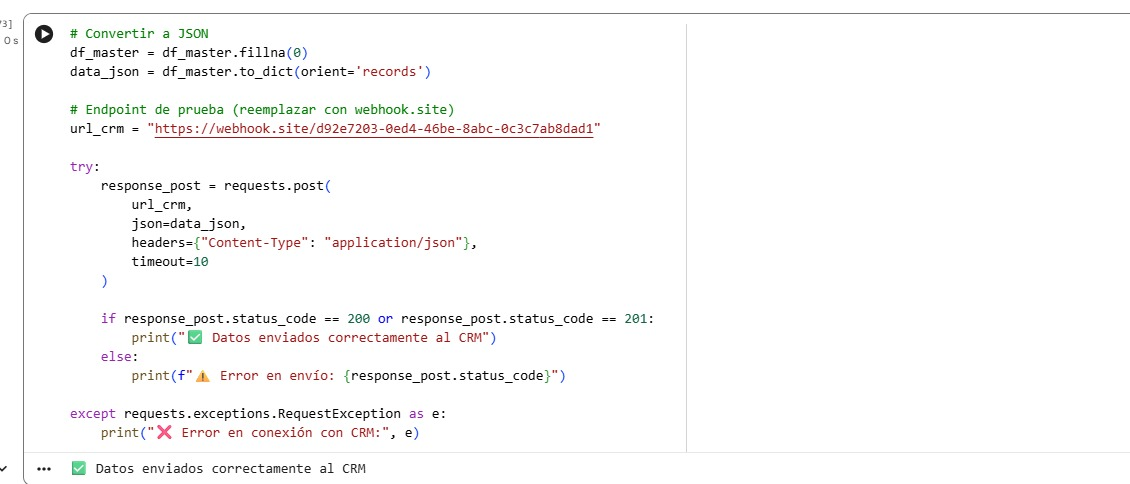

## Captura de código funcionando, datos llegan al servidor:

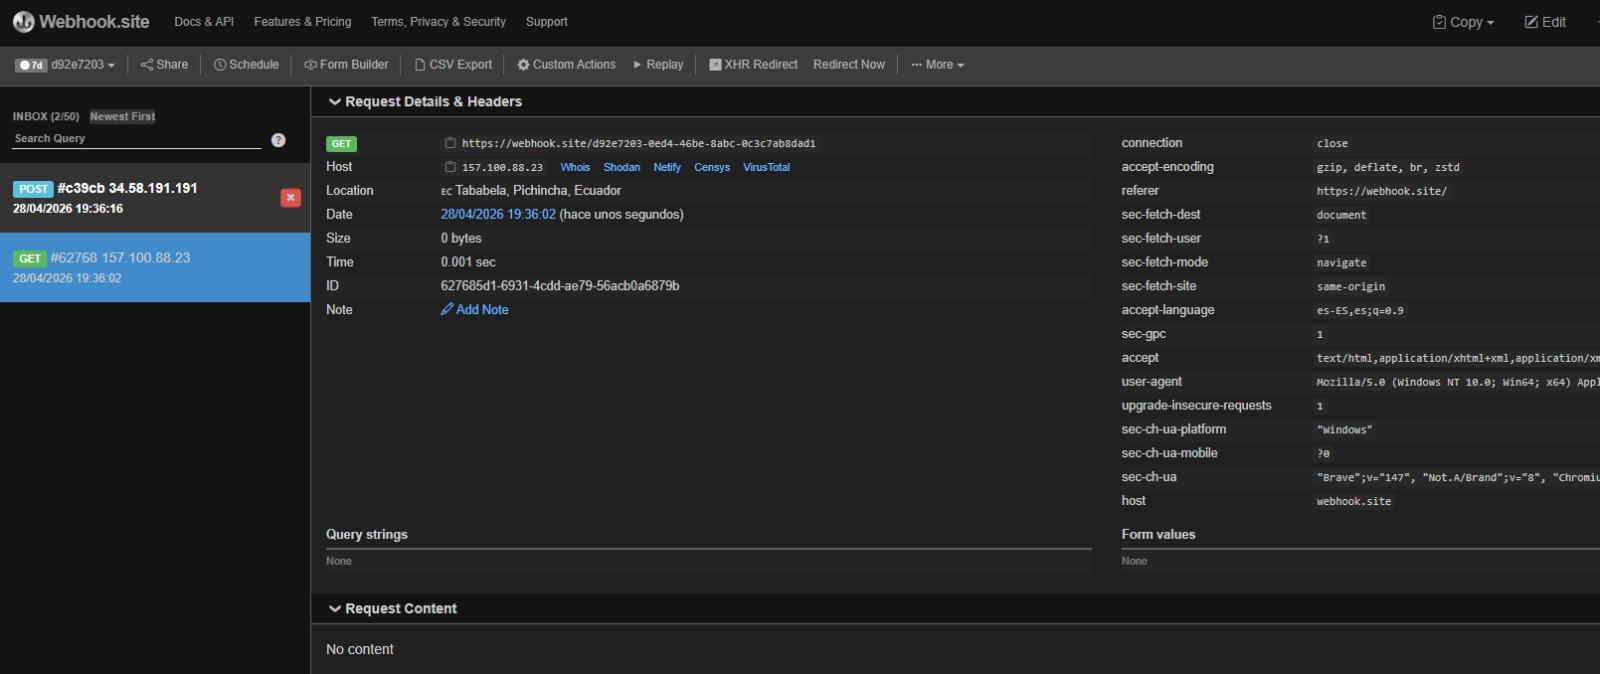